# **Persamaan Eliptik**

Persamaan Eliptik adalah salah satu klasifikasi Persamaan Diferensial Parsial (PDE) yang sering digunakan untuk menggambarkan kondisi setimbang (steady-state) dalam suatu sistem.
Persamaan eliptik dalam dimensi yang lebih tinggi secara umum memiliki bentuk:

$$a_1u_{xx} + a_2u_{xy} + a_3u_{yy} + a_4u_x + a_5u_y + a_6u = f$$

di mana koefisien-koefisiennya harus memenuhi syarat:

$$a_2^2 - 4a_1a_3 < 0.$$

Salah satu contoh alami di mana persamaan seperti ini muncul adalah pada masalah steady-state (keadaan tunak) yang berasal dari persamaan panas. Dalam dua dimensi, kita memiliki:

$$u_t = (\kappa u_x)_x + (\kappa u_y)_y + \Psi(x, y).$$

Jika $u_t = 0$, maka kita mendapatkan:

$$(\kappa u_x)_x + (\kappa u_y)_y = -\Psi(x, y).$$

jika kita mengasumsikan $\kappa$ sebagai konstanta, kita dapat menulis ulang persamaan ini menjadi:

$$u_{xx} + u_{yy} = -\frac{\Psi}{\kappa} = f(x, y)$$

yang merupakan bentuk dimensi yang lebih tinggi dari persamaan Poisson (dan menjadi persamaan Laplace jika $f(x, y) = 0$).

Kita juga harus menentukan domain $\Omega$ dan syarat batas seperti sebelumnya. Sekarang, syarat batas akan memiliki ketergantungan pada $x$ dan $y$, sehingga perlu ditangani sedikit berbeda dari sebelumnya.



# **Stensil 5-Titik (5-Point Stencil)**

Stensil 5-Titik (5-Point Stencil) adalah sebuah metode dalam analisis numerik yang digunakan untuk mendekati nilai turunan (khususnya Laplacian $\nabla^2$) pada sebuah titik dalam kisi dua dimensi ($2D$ grid).

Dengan memperluas pengerjaan kita dari satu dimensi ke dua dimensi, kita dapat membangun stensil 5-titik untuk operator Laplacian sebagai berikut:

$$\nabla^2 u \approx \frac{U_{i-1,j} - 2U_{i,j} + U_{i+1,j}}{\Delta x^2} + \frac{U_{i,j-1} - 2U_{i,j} + U_{i,j+1}}{\Delta y^2}$$

Jika $\Delta x = \Delta y$, kita dapat menyederhanakan ekspresi ini menjadi:

$$\nabla^2 u \approx \frac{U_{i-1,j} + U_{i+1,j} - 4U_{i,j} + U_{i,j-1} + U_{i,j+1}}{\Delta x^2}$$

Kita kemudian dapat memperkirakan solusi untuk persamaan Poisson sebagai:
$$\frac{U_{i-1,j} + U_{i+1,j} - 4U_{i,j} + U_{i,j-1} + U_{i,j+1}}{\Delta x^2} = f_{i,j}$$

yang menghasilkan $m^2$ persamaan untuk $m^2$ variabel yang tidak diketahui.



## **Pengurutan Variabel yang Tidak Diketahui (Ordering of Unknowns)**
Pengurutan Variabel yang Tidak Diketahui (Ordering of Unknowns) adalah cara kita memberikan nomor urut pada titik-titik di dalam grid (kisi) agar bisa disusun menjadi sebuah vektor dan matriks besar yang dapat diselesaikan oleh komputer.

Kita dapat membayangkan masalah dua dimensi kita terletak pada sebuah kisi (grid) seperti pada gambar berikut. Di sini, variabel yang tidak diketahui berwarna merah dan batas-batasnya berwarna biru:
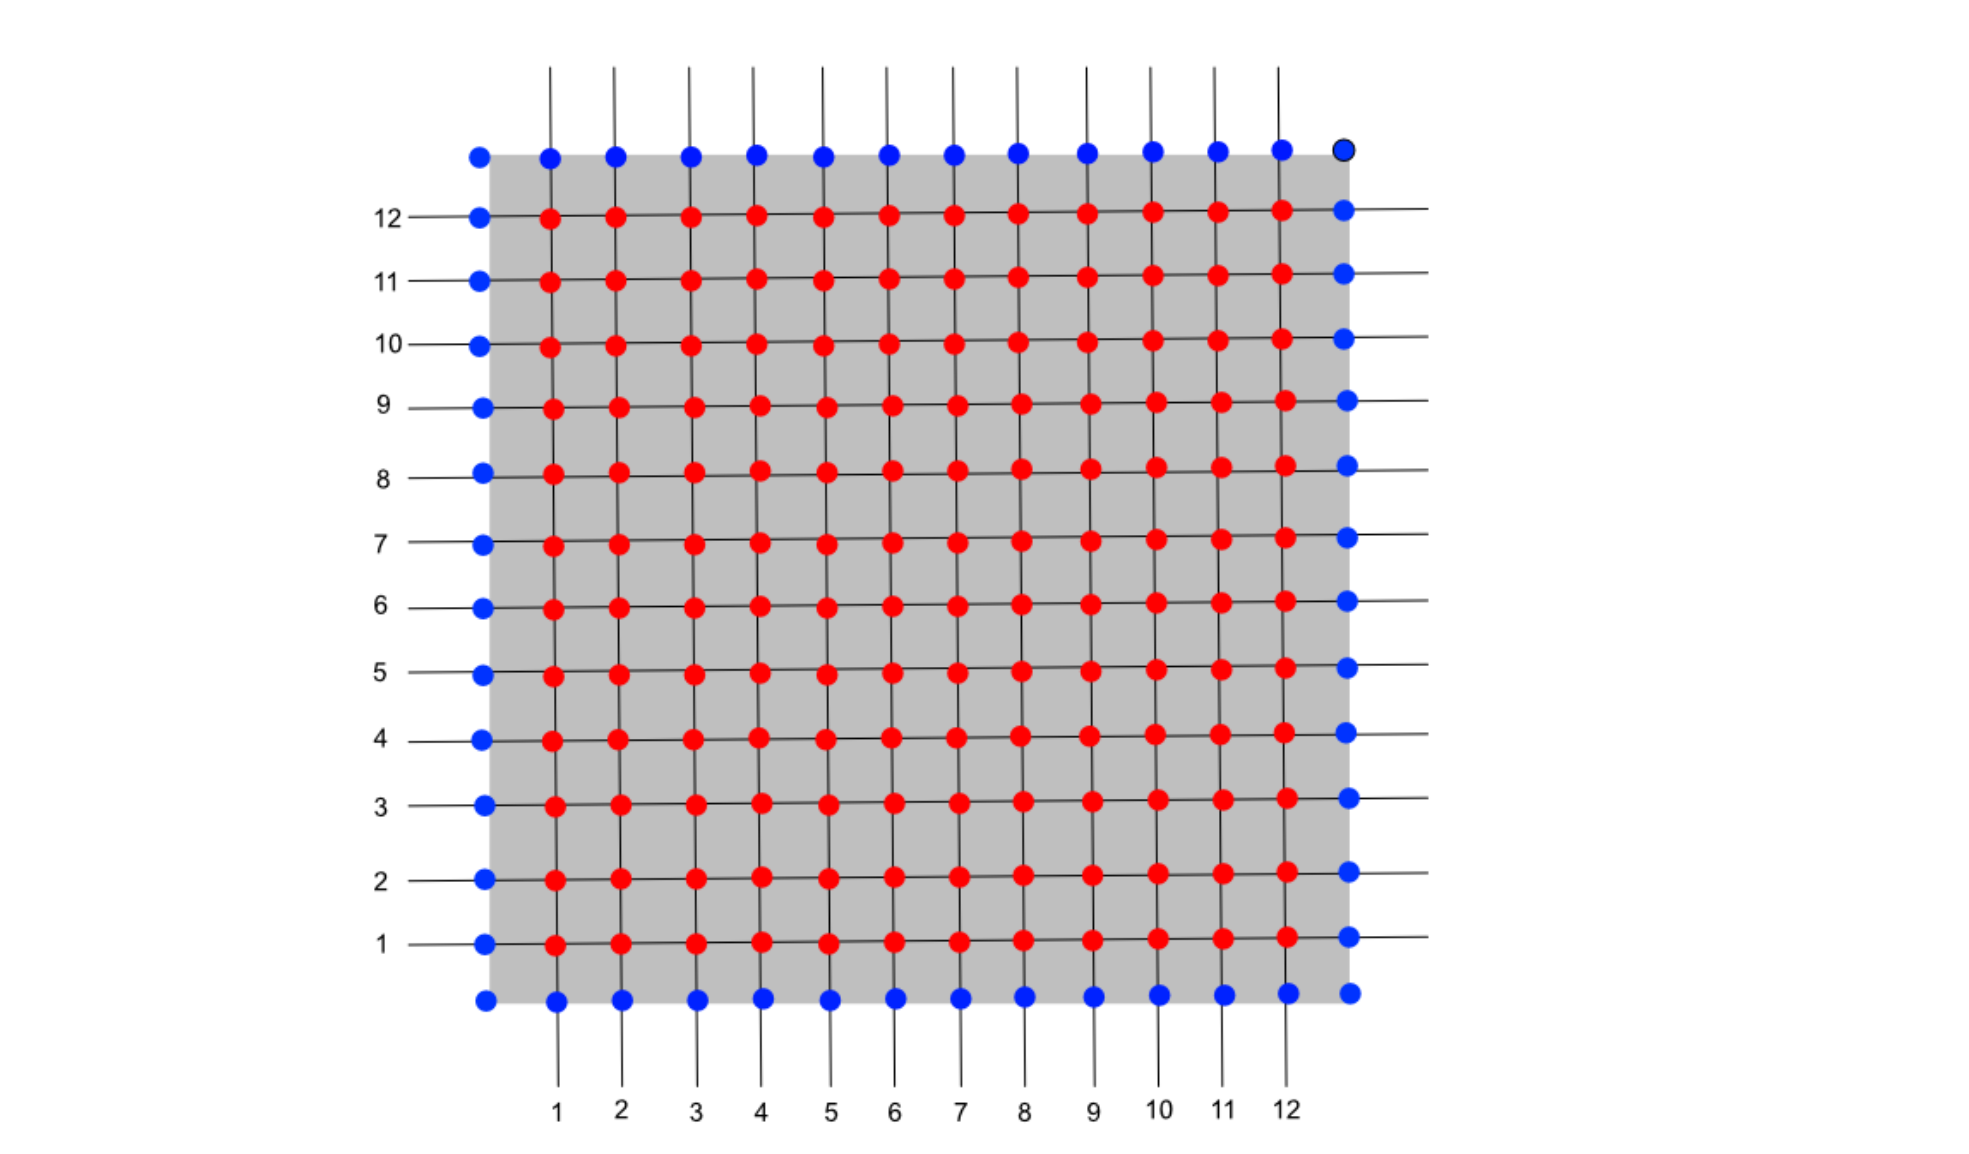

Kita dapat membayangkan kisi (grid) tersebut sebagai sebuah matriks seperti:

$$U = \begin{bmatrix}
U_{1,m} & U_{2,m} & \cdots & U_{m-1,m} & U_{m,m} \
U_{1,m-1} & U_{2,m-1} & \cdots & U_{m-1,m-1} & U_{m,m-1} \
\vdots & & & & \vdots \
U_{1,2} & U_{2,2} & \cdots & U_{m-1,2} & U_{m,2} \
U_{1,1} & U_{2,1} & \cdots & U_{m-1,1} & U_{m,1}
\end{bmatrix}$$

Penting untuk dicatat bahwa pelabelan ini tidak sama dengan notasi matriks kita yang biasanya!

Ketika kita bekerja dalam satu dimensi, pengurutan variabel yang tidak diketahui (dan persamaannya) cukup jelas, tetapi sekarang kita memiliki beberapa pilihan yang harus dibuat. Mungkin pilihan yang paling jelas adalah membagi array 2D tersebut menjadi baris-baris dan menyambungkan setiap baris ke akhir baris sebelumnya. Hal ini menghasilkan pengurutan:

$$U = [U_{1,1}, U_{2,1}, \dots, U_{m-1,1}, U_{m,1}, U_{1,2}, U_{2,2}, \dots, U_{m-1,m}, U_{mm}]$$

Hal ini menghasilkan matriks dengan bentuk:

$$
    A = \frac{1}{\Delta x^2} \begin{bmatrix}
        T & I \\
        I & T & I \\
          & I & T & I \\
          &   & \ddots & \ddots & \ddots \\
          &   &        & I & T & I \\
          &   &        &   & I & T
    \end{bmatrix}
$$
di mana matriks $T$ adalah:

$$
    T = \begin{bmatrix}
        -4 & 1 \\
        1 & -4 & 1 \\
          & 1 & -4 & 1 \\
          &   & \ddots & \ddots & \ddots \\
          &   &        & 1 & -4 & 1 \\
          &   &        &   & 1 & -4
    \end{bmatrix}
$$

dan $I$ adalah matriks identitas berukuran $m \times m$.


Kemungkinan lain adalah pengurutan merah-hitam (red-black ordering), yang menyerupai pola papan catur. Di sini kita "mewarnai" setiap variabel yang tidak diketahui pada kisi kita dengan warna yang bergantian, kemudian setiap variabel dengan warna yang sama dikelompokkan menjadi satu.
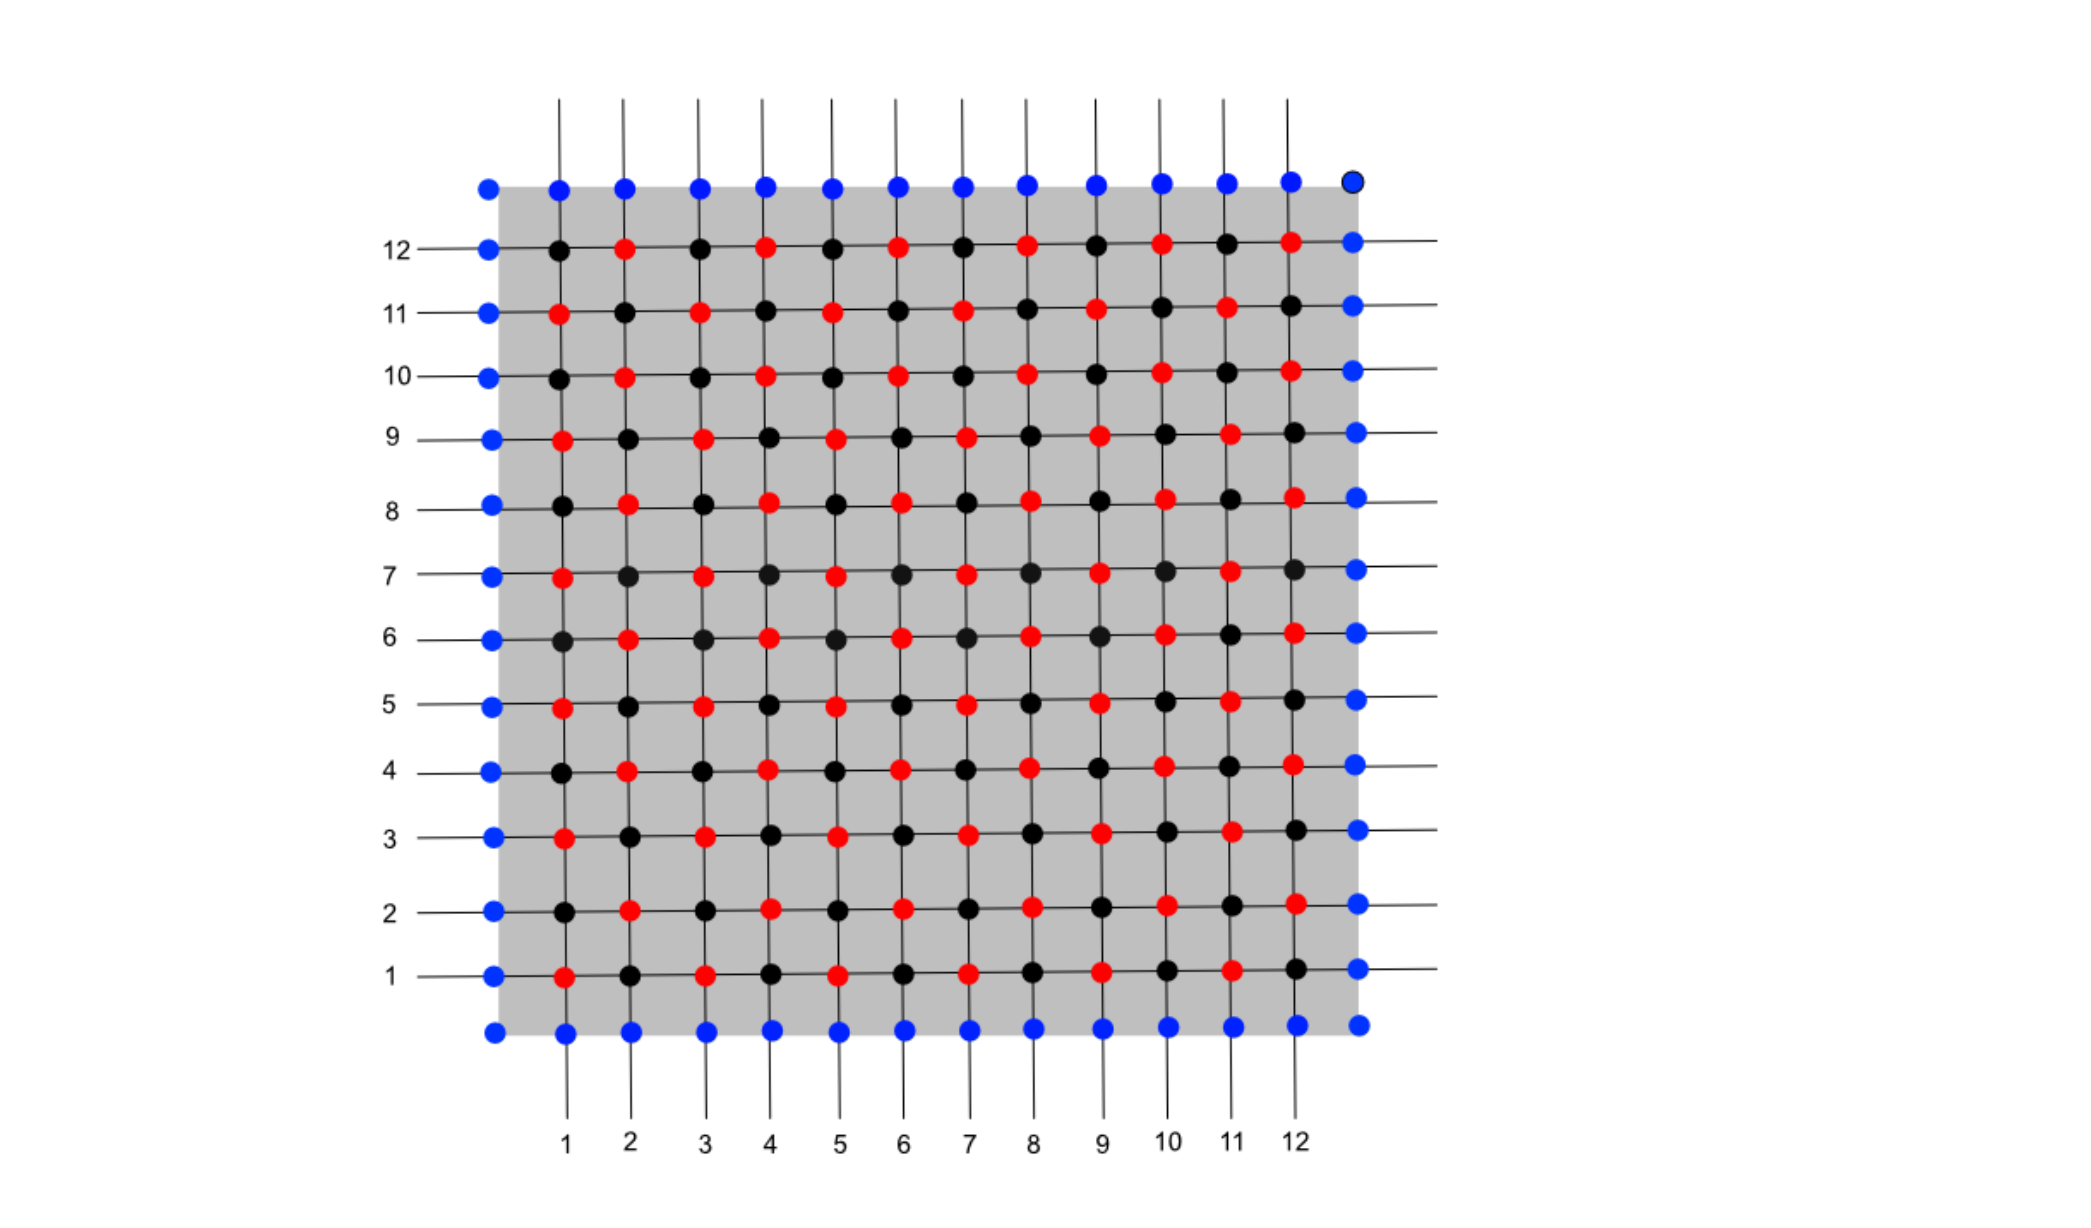

Untuk pengurutan merah-hitam, kita diarahkan pada bentuk matriks berikut:
$$\begin{bmatrix} D & H \\ H^T & D \end{bmatrix} \begin{bmatrix} U_{\text{merah}} \\ U_{\text{hitam}} \end{bmatrix} = \begin{bmatrix} f_{\text{merah}} \\ f_{\text{hitam}} \end{bmatrix}$$

Di sini, $D = -4/\Delta x^2 I$ adalah sebuah matriks diagonal dengan dimensi $m^2/2$, dan $H$ adalah sebuah banded matrix dengan 4 diagonal non-nol.
Biasanya, tujuan dari pengurutan adalah untuk membuat celah di antara elemen-elemen non-nol sekecil mungkin dan mengurangi jumlah "fill-in" saat menyelesaikan persamaan menggunakan metode seperti eliminasi Gaussian. Hal ini sering kali ditangani secara otomatis saat menggunakan rutinitas penyelesaian (solving routines) yang canggih.

Selesaikan PDE berikut menggunakan pengurutan pilihan Anda:

$$\nabla^2 u = -2 \sin x \sin y \quad \Omega = [0, 2\pi] \times [0, 2\pi]$$

$$u(x, 0) = 0, u(x, 2\pi) = 0, u(0, y) = 0, u(2\pi, y) = 0.$$


0.0012900074949673457


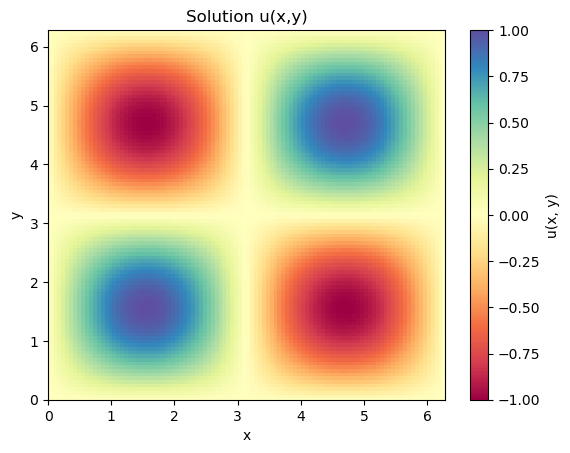

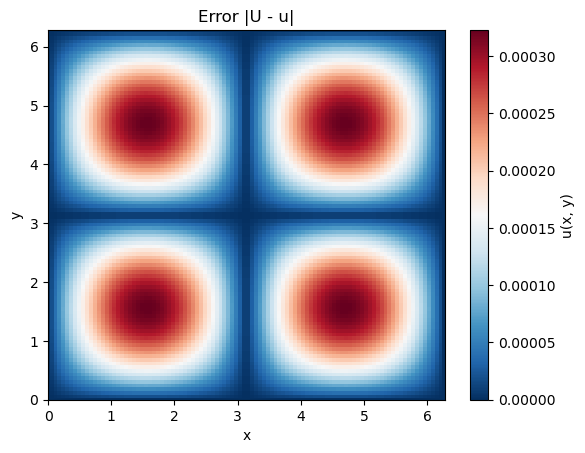

In [16]:
import numpy                              # Mengimpor library NumPy untuk operasi numerik dan array
import matplotlib.pyplot as plt           # Mengimpor matplotlib untuk membuat grafik
import scipy.sparse as sparse             # Mengimpor modul sparse matrix dari SciPy
import scipy.sparse.linalg as linalg      # Mengimpor solver matriks sparse

# Problem specification
m = 100                                   # Jumlah titik grid interior pada domain
x = numpy.linspace(0, 2.0 * numpy.pi, m + 2)  # Membuat grid x dari 0 sampai 2π dengan m+2 titik (termasuk boundary)
y = numpy.linspace(0, 2.0 * numpy.pi, m + 2)  # Membuat grid y dari 0 sampai 2π dengan m+2 titik
delta_x = 2.0 * numpy.pi / (m + 1)            # Menghitung jarak antar grid Δx

# Construct A (Membangun matriks Laplacian diskrit)
e = numpy.ones(m)                         # Membuat vektor berisi angka 1 sebanyak m elemen
T = sparse.spdiags([e, -4.0 * e, e], [-1, 0, 1], m, m)  
# Membuat matriks tridiagonal dengan diagonal [-1,0,1] untuk operator Laplacian arah x

S = sparse.spdiags([e, e], [-1, 1], m, m) 
# Membuat matriks dengan diagonal atas dan bawah untuk hubungan arah y  

I = sparse.eye(m)                         # Membuat matriks identitas ukuran m x m

A = sparse.kron(I, T) + sparse.kron(S, I) # Membentuk matriks Laplacian 2D menggunakan produk Kronecker

A /= delta_x**2                           # Membagi matriks dengan Δx² sesuai diskretisasi operator Laplacian

# Right-hand-side (fungsi sumber)
X, Y = numpy.meshgrid(x[1:-1], y[1:-1])   # Membuat grid 2D untuk titik interior domain

f = -2.0 * numpy.sin(X) * numpy.sin(Y)    # Mendefinisikan fungsi sumber f(x,y)

# Solve (menyelesaikan sistem persamaan linear)
U = numpy.zeros((m+2, m+2))               # Membuat matriks solusi dengan ukuran termasuk boundary

U[1:-1, 1:-1] = linalg.spsolve(A, f.reshape(m**2, order='F')).reshape((m, m), order='F')
# Menyelesaikan sistem AU = f menggunakan solver sparse
# reshape digunakan untuk mengubah bentuk array dari 2D ke 1D dan kembali ke 2D

# Error (menghitung error antara solusi numerik dan solusi analitik)
X, Y = numpy.meshgrid(x, y)               # Membuat kembali grid penuh termasuk boundary

print(numpy.linalg.norm((x[1] - x[0]) * (U - numpy.sin(X) * numpy.sin(Y)), ord=1))
# Menghitung norma error L1 antara solusi numerik U dan solusi analitik sin(x)sin(y)

# Plot solution (visualisasi solusi numerik)
fig = plt.figure()                        # Membuat figure baru
axes = fig.add_subplot(1, 1, 1)           # Membuat subplot

sol_plot = axes.pcolor(X, Y, U, cmap=plt.get_cmap('Spectral'))  
# Membuat plot warna (heatmap) dari solusi U(x,y)

axes.set_title("Solution u(x,y)")         # Judul grafik
axes.set_xlabel("x")                      # Label sumbu x
axes.set_ylabel("y")                      # Label sumbu y

axes.set_xlim((0.0, 2.0 * numpy.pi))     # Batas sumbu x
axes.set_ylim((0.0, 2.0 * numpy.pi))     # Batas sumbu y

cbar = fig.colorbar(sol_plot, ax=axes)   # Menambahkan colorbar
cbar.set_label("u(x, y)")                # Label colorbar

# Plot error (visualisasi error solusi)
fig = plt.figure()                       # Membuat figure baru
axes = fig.add_subplot(1, 1, 1)          # Membuat subplot

sol_plot = axes.pcolor(X, Y, numpy.abs(U - numpy.sin(X) * numpy.sin(Y)), cmap=plt.get_cmap('RdBu_r'))
# Membuat plot distribusi error |U - u|

axes.set_title("Error |U - u|")          # Judul grafik error
axes.set_xlabel("x")                     # Label sumbu x
axes.set_ylabel("y")                     # Label sumbu y

axes.set_xlim((0.0, 2.0 * numpy.pi))    # Batas sumbu x
axes.set_ylim((0.0, 2.0 * numpy.pi))    # Batas sumbu y

cbar = fig.colorbar(sol_plot, ax=axes)  # Menambahkan colorbar
cbar.set_label("u(x, y)")               # Label colorbar

plt.show()                              # Menampilkan semua grafik

## **Akurasi dan Stabilitas**

Akurasi adalah tingkat kedekatan hasil perhitungan numerik dengan nilai sebenarnya (solusi analitik).Stabilitas adalah kemampuan metode numerik untuk mengendalikan error agar tidak semakin besar selama perhitungan.

Kita tentu saja bisa (dan seharusnya) menanyakan pertanyaan yang sama seperti pada kasus satu dimensi, yaitu apakah skema kita akan konvergen. Untuk melakukan ini, kita perlu mempertimbangkan LTE (Local Truncation Error) dan stabilitas metode kita.

Kita tahu bahwa LTE didefinisikan sebagai:
$$\tau_{ij} = \frac{1}{\Delta x^2} (u(x_{i-1}, y_j) + u(x_{i+1}, y_j) + u(x_i, y_{j-1}) + u(x_i, y_{j+1}) - 4u(x_i, y_j)) - f(x_i, y_j)$$

Untuk menghitung ekspresi ini, kita memerlukan deret Taylor pada setiap arah.

Untuk arah-x:

$$u(x_{i+1}, y_j) = u(x_i, y_j) + \Delta x u(x_i, y_j)_x + \frac{\Delta x^2}{2} u(x_i, y_j)_{xx} + \frac{\Delta x^3}{6} u(x_i, y_j)_{xxx} + \frac{\Delta x^4}{24} u(x_i, y_j)_{xxxx} + \mathcal{O}(\Delta x^5)$$

$$u(x_{i-1}, y_j) = u(x_i, y_j) - \Delta x u(x_i, y_j)_x + \frac{\Delta x^2}{2} u(x_i, y_j)_{xx} - \frac{\Delta x^3}{6} u(x_i, y_j)_{xxx} + \frac{\Delta x^4}{24} u(x_i, y_j)_{xxxx} + \mathcal{O}(\Delta x^5)$$

Untuk Arah-y:
Sama seperti arah horizontal sebelumnya, kita juga perlu membuat "ramalan" untuk titik-titik di atas dan di bawah kita:

$$u(x_i, y_{j+1}) = u(x_i, y_j) + \Delta y u(x_i, y_j)_y + \frac{\Delta y^2}{2} u(x_i, y_j)_{yy} + \frac{\Delta y^3}{6} u(x_i, y_j)_{yyy} + \frac{\Delta y^4}{24} u(x_i, y_j)_{yyyy} + \mathcal{O}(\Delta y^5)$$

$$u(x_i, y_{j-1}) = u(x_i, y_j) - \Delta y u(x_i, y_j)_y + \frac{\Delta y^2}{2} u(x_i, y_j)_{yy} - \frac{\Delta y^3}{6} u(x_i, y_j)_{yyy} + \frac{\Delta y^4}{24} u(x_i, y_j)_{yyyy} + \mathcal{O}(\Delta y^5)$$
Menghitung Error Akhir (LTE):
Juga dengan menggunakan ekspansi Taylor pada arah-y, kita dapat menuliskan LTE (kesalahan metode ini) sebagai:

$$\tau_{ij} = \frac{1}{12} \Delta x^2 (u_{xxxx} + u_{yyyy}) + \mathcal{O}(\Delta x^4)$$



Kumpulan semua error di setiap titik dapat disusun menjadi satu sistem persamaan besar:

$$A_{\Delta x} E_{\Delta x} = -\tau_{\Delta x}$$

Di mana $A$ adalah aturan matematika (diskritisasi) yang kita gunakan, dan urutan pengerjaannya tidak berpengaruh pada nilai errornya.
Untuk memastikan hitungan komputer tidak "meledak" atau kacau, kita memeriksa nilai Eigenvalues ($\lambda_{pq}$):
$$\lambda_{pq} = \frac{2}{\Delta x^2} ((\cos(p \pi \Delta x) - 1) + (\cos(q \pi \Delta x) - 1))$$

Dengan pola sebaran error (Eigenvectors) sebagai berikut:

$$v_{ij}^{p,q} = \sin(p \pi i \Delta x) \sin(q \pi j \Delta x)$$



Konvergensi dan Kondisi Matriks

Karena eigenvalues bernilai negatif ketat ($A$ sebenarnya adalah negative definite), nilai yang paling dekat dengan titik asal (origin) adalah:

$$\lambda_{11} = -2\pi^2 + \mathcal{O}(\Delta x^2)$$

Hal ini mengarah pada radius spektral:

$$\rho((A^{\Delta x})^{-1}) = \frac{1}{\lambda_{11}} \approx -\frac{1}{2\pi^2}$$

Kita dapat menggunakan batasan pada $A^{-1}$ ini untuk menunjukkan stabilitas dan konvergensi dari diskritisasi tersebut.

Besaran serupa yang berguna untuk dipertimbangkan adalah condition number (bilangan kondisi) dari matriks $A$, yang didefinisikan sebagai:

$$\kappa(A) = \|A\| \|A^{-1}\|$$

Bilangan Kondisi (Condition Number)

Ini adalah ukuran sensitivitas matriks terhadap perubahan kecil atau error:

Eigenvalue Terbesar:
Dalam 2-norm, nilai karakteristik terbesarnya adalah:
$$\lambda_{mm} \approx -\frac{8}{\Delta x^2}$$

Sehingga menghasilkan bilangan kondisi:
$$\kappa_2(A) = \frac{4}{\pi^2 \Delta x^2} = \mathcal{O}\left(\frac{1}{\Delta x^2}\right)$$

Matriks ini pun menjadi lebih ill-conditioned (sulit dipecahkan secara akurat oleh komputer) seiring $\Delta x \rightarrow 0$.



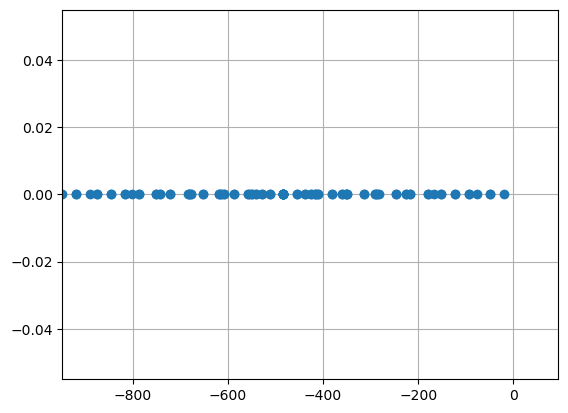

In [1]:
import numpy                 # Mengimpor library NumPy untuk operasi numerik
import matplotlib.pyplot as plt   # Mengimpor matplotlib untuk membuat grafik

# Compute the eigenvalues
m = 10                       # Jumlah titik grid interior pada domain
delta_x = 1.0 / float(m + 1) # Menghitung jarak antar grid Δx = 1/(m+1)

eig_vals = numpy.empty(m**2) # Membuat array kosong berukuran m^2 untuk menyimpan eigenvalue

for (i, p) in enumerate(numpy.arange(1, m + 1)):   # Loop pertama: p adalah mode arah x, i adalah indeks
    for (j, q) in enumerate(numpy.arange(1, m + 1)): # Loop kedua: q adalah mode arah y, j adalah indeks
        
        eig_vals[i * m + j] = 2.0 / delta_x**2 * (  # Menyimpan hasil eigenvalue pada indeks array
            (numpy.cos(p * numpy.pi * delta_x) - 1.0) +  # Komponen eigenvalue dari arah x
            (numpy.cos(q * numpy.pi * delta_x) - 1.0)    # Komponen eigenvalue dari arah y
        )

# Plot of the eigenvalues of the 5-point Laplacian
fig = plt.figure()             # Membuat objek gambar (figure)

axes = fig.add_subplot(1, 1, 1) # Membuat subplot dengan layout 1x1 dan memilih plot pertama

axes.plot(eig_vals.real, eig_vals.imag, 'o')  # Memplot eigenvalue (real vs imaginary) dengan marker titik

axes.grid(True)                # Menampilkan grid pada grafik

axes.set_xlim(numpy.amin(eig_vals), -numpy.amin(eig_vals) * 0.1) 
# Mengatur batas sumbu x dari nilai eigen terkecil sampai sebagian kecil sisi kanan

plt.show()                     # Menampilkan grafik

## **Pendekatan Lain: Laplacian 9-Titik**
adalah metode diskretisasi yang digunakan dalam metode beda hingga (finite difference) untuk menghitung operator Laplacian pada persamaan diferensial parsial (PDE), seperti persamaan Poisson atau panas.


Pendekatan lain untuk mendiskritisasi Laplacian $\nabla^2$ disebut dengan stencil 9-titik. Stencil ini didefinisikan sebagai:

$$\nabla^2 u_{ij} = \frac{1}{6\Delta x^2} (4u_{i-1,j} + 4u_{i+1,j} + 4u_{i,j-1} + 4u_{i,j+1} + u_{i-1,j-1} + u_{i+1,j-1} + u_{i+1,j+1} + u_{i-1,j+1} - 20u_{i,j})$$

Kita juga dapat menemukan LTE seperti sebelumnya untuk mendapatkan:

$$\tau_{ij} = \frac{\Delta x^2}{12} (u_{xxxx} + 2u_{xxyy} + u_{yyyy}) + \mathcal{O}(\Delta x^4)$$

Apa yang Kita Dapatkan?
jika kita melihat $\tau_{ij}$, kita dapat menuliskan suku turunannya sebagai:
$$u_{xxxx} + 2u_{xxyy} + u_{yyyy} = \nabla^2(\nabla^2 u) \equiv \nabla^4 u$$
Yaitu Laplacian dari Laplacian (disebut sebagai biharmonic operator). Jika kita kembali ke PDE aslinya, kita dapat langsung menemukan bentuk error ini dengan mencatat:

$$\nabla^2 u = f$$
$$\nabla^2(\nabla^2 u) = \nabla^2 f$$

Kita dapat menghitung suku error secara langsung dengan mengambil Laplacian dari sisi kanan PDE aslinya! Hal ini juga dapat mengarah pada metode orde yang lebih tinggi. Jika kita mendefinisikan:

$$f_{ij} = f(x_i, y_j) + \frac{\Delta x^2}{12} \nabla^2 f(x_i, y_j)$$

kita dapat membatalkan suku LTE berikutnya! Kita bahkan dapat melakukan ini jika kita hanya memiliki fungsi $f(x, y)$ pada sekumpulan titik diskrit karena kita dapat menggunakan stencil 5-titik.


